# LDLR AlphaGenome predictions -- c.-121T>C -- ref, alt, and their difference

HepG2 RNA-seq predictions for `c.-121T>C`, at `K=0` (no random-offset shift --
variant sits at its real genomic position, no padding inserted). Window is
`chr19:11,037,002-11,168,073` (GRCh38), 131,072 bp.

Same variant window as `c.-120C>T` (they're adjacent SNPs, both ~34 bp
upstream of the TSS) -- this notebook repeats the same 10-plot analysis for
this second variant.

Exon coordinates are the canonical LDLR transcript (Ensembl `ENST00000558518`
/ RefSeq `NM_000527.5`), 18 exons. The 5'UTR occupies the first 86 bp of exon 1
(TSS to ATG); the 3'UTR occupies the last part of exon 18 (stop codon to
poly-A site).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRED_DIR = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/8-aphagenome/pytorch/predictions_ldlr_1bp/c.-121T_C"
VARIANT_LABEL = "c.-121T>C"

meta = pd.read_csv(f"{PRED_DIR}/meta.tsv", sep="\t")
row0 = meta.loc[meta["K"] == 0].iloc[0]
row_idx = int(row0["window_idx"])
window_start = int(row0["window_start"])
window_end = int(row0["window_end"])
var_pos_hg38 = int(row0["var_pos_hg38"])

ref = np.load(f"{PRED_DIR}/ref.npy", mmap_mode="r")
alt = np.load(f"{PRED_DIR}/alt.npy", mmap_mode="r")
signal_ref = np.asarray(ref[row_idx], dtype=np.float32)
signal_alt = np.asarray(alt[row_idx], dtype=np.float32)
x = np.arange(len(signal_ref))  # bp offset from window_start

print(f"row_idx={row_idx}  window={window_start}-{window_end}  var_pos_hg38={var_pos_hg38}")
print(f"signal shape: {signal_ref.shape}")

row_idx=0  window=11037002-11168073  var_pos_hg38=11089428
signal shape: (131072,)


In [2]:
# LDLR exons, GRCh38, canonical transcript ENST00000558518 / RefSeq NM_000527.5
# (1-based inclusive genomic coordinates, + strand)
EXONS_HG38 = [
    (1, 11_089_463, 11_089_615),
    (2, 11_100_223, 11_100_345),
    (3, 11_102_664, 11_102_786),
    (4, 11_105_220, 11_105_600),
    (5, 11_106_565, 11_106_687),
    (6, 11_107_392, 11_107_514),
    (7, 11_110_652, 11_110_771),
    (8, 11_111_514, 11_111_639),
    (9, 11_113_278, 11_113_449),
    (10, 11_113_535, 11_113_762),
    (11, 11_116_094, 11_116_212),
    (12, 11_116_859, 11_116_998),
    (13, 11_120_092, 11_120_233),
    (14, 11_120_370, 11_120_522),
    (15, 11_123_174, 11_123_344),
    (16, 11_128_008, 11_128_085),
    (17, 11_129_513, 11_129_670),
    (18, 11_131_281, 11_133_820),
]
ATG_HG38 = 11_089_549      # A of the start codon (c.1), inside exon 1
CDS_END_HG38 = 11_131_316  # last nt of the stop codon, inside exon 18

exons_in_window = pd.DataFrame(EXONS_HG38, columns=["exon", "start_hg38", "end_hg38"])
exons_in_window["start_off"] = exons_in_window["start_hg38"] - window_start
exons_in_window["end_off"] = exons_in_window["end_hg38"] - window_start
atg_off = ATG_HG38 - window_start
cds_end_off = CDS_END_HG38 - window_start
var_off = var_pos_hg38 - window_start

exon1 = exons_in_window.iloc[0]
exon18 = exons_in_window.iloc[-1]
gap_bp = int(exon1["start_off"] - var_off)

FULL_XLIM = (0, len(signal_ref))
EXON1_XLIM = (var_off - 300, exon1["end_off"] + 200)
EXON18_XLIM = (exon18["start_off"] - 300, exon18["end_off"] + 300)

exons_in_window

,exon,start_hg38,end_hg38,start_off,end_off
0,1,11089463,11089615,52461,52613
1,2,11100223,11100345,63221,63343
2,3,11102664,11102786,65662,65784
3,4,11105220,11105600,68218,68598
4,5,11106565,11106687,69563,69685
5,6,11107392,11107514,70390,70512
6,7,11110652,11110771,73650,73769
7,8,11111514,11111639,74512,74637
8,9,11113278,11113449,76276,76447
9,10,11113535,11113762,76533,76760


In [3]:
COLOR_SIGNAL = "#1b4965"   # ref/alt prediction line
COLOR_CDS = "#4a90c9"      # coding exon (fixed hue #1)
COLOR_UTR = "#e8a04c"      # UTR (fixed hue #2)
COLOR_VARIANT = "#c0392b"  # variant callout, used sparingly
COLOR_UP = "#4a90c9"       # diff > 0 (ref > alt)
COLOR_DOWN = "#c0392b"     # diff < 0 (ref < alt)


def draw_exon_shading(ax, show_exon_numbers):
    """CDS/UTR spans for every exon, split at the ATG (exon 1) and stop codon (exon 18)."""
    cds_labeled = utr_labeled = False
    for _, e in exons_in_window.iterrows():
        s, en = e["start_off"], e["end_off"]
        if e["exon"] == 1:
            segs = [(s, atg_off, COLOR_UTR), (atg_off, en, COLOR_CDS)]
        elif e["exon"] == 18:
            segs = [(s, cds_end_off, COLOR_CDS), (cds_end_off, en, COLOR_UTR)]
        else:
            segs = [(s, en, COLOR_CDS)]

        for seg_s, seg_e, color in segs:
            label = None
            if color == COLOR_CDS and not cds_labeled:
                label, cds_labeled = "CDS exon", True
            elif color == COLOR_UTR and not utr_labeled:
                label, utr_labeled = "UTR", True
            ax.axvspan(seg_s, seg_e, color=color, alpha=0.35, lw=0, zorder=1, label=label)

        if show_exon_numbers:
            # blended transform: x in data coords, y in axes-fraction -- so this label
            # never feeds back into y-axis autoscaling (which matters once data, e.g.
            # a small ref-alt diff, has a much smaller range than the default (0, 1))
            ax.text((s + en) / 2, 1.0, str(int(e["exon"])), transform=ax.get_xaxis_transform(),
                    fontsize=6, ha="center", va="bottom", color="#555555", rotation=90, clip_on=False)


def plot_window(sig, xlim, title, diverging=False, zoom=None):
    """One plot: exon/UTR shading + signal (or ref-alt diff) + variant/landmark lines.

    zoom: None (full window, exon numbers shown) | "exon1" | "exon18" (zoomed, ATG /
    stop-codon marker + annotations shown for that region).
    """
    fig, ax = plt.subplots(figsize=(16, 4.5) if zoom is None else (12, 4))

    draw_exon_shading(ax, show_exon_numbers=(zoom is None))

    if diverging:
        ax.fill_between(x, 0, sig, where=(sig >= 0), color=COLOR_UP, linewidth=0, zorder=2)
        ax.fill_between(x, 0, sig, where=(sig < 0), color=COLOR_DOWN, linewidth=0, zorder=2)
        ax.plot(x, sig, color="#333333", linewidth=0.6, zorder=3)
        ax.axhline(0, color="#888888", linewidth=0.8, zorder=2)
        ylabel = "ref - alt (predicted HepG2 RNA-seq signal)"
    else:
        marker = "o" if zoom == "exon1" else None
        ax.plot(x, sig, color=COLOR_SIGNAL, linewidth=1.2 if zoom else 0.8,
                marker=marker, markersize=2, zorder=3)
        ylabel = "predicted HepG2 RNA-seq signal"

    ax.axvline(var_off, color=COLOR_VARIANT, linewidth=1.2, linestyle="--", zorder=4, label=VARIANT_LABEL)

    if zoom == "exon1":
        ax.axvline(atg_off, color="#444444", linewidth=1, linestyle=":", zorder=4, label="ATG (c.1)")
        ax.annotate(f"exon 1 starts\n({exon1['start_hg38']:,})",
                    xy=(exon1["start_off"], ax.get_ylim()[1] * 0.9), fontsize=8, ha="left")
        ax.annotate(f"{gap_bp} bp gap\n(promoter)",
                    xy=((var_off + exon1["start_off"]) / 2, 0),
                    xytext=((var_off + exon1["start_off"]) / 2, ax.get_ylim()[0]),
                    fontsize=8, ha="center", va="top", annotation_clip=False)
    elif zoom == "exon18":
        ax.axvline(cds_end_off, color="#444444", linewidth=1, linestyle=":", zorder=4, label="stop codon")
        ax.annotate(f"exon 18 starts\n({exon18['start_hg38']:,})",
                    xy=(exon18["start_off"], ax.get_ylim()[1] * 0.9), fontsize=8, ha="left")
        ax.annotate(f"exon 18 ends\n({exon18['end_hg38']:,})",
                    xy=(exon18["end_off"], ax.get_ylim()[1] * 0.9), fontsize=8, ha="right")

    ax.set_xlim(*xlim)
    ax.set_xlabel(f"position (bp offset from window_start={window_start:,}, chr19)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_three(sig, label, diverging=False):
    """Full window, exon 1 zoom, exon 18 zoom -- for one signal array."""
    plot_window(sig, FULL_XLIM, f"LDLR -- {label}, full 131,072 bp window (K=0, no offset)", diverging=diverging, zoom=None)
    plot_window(sig, EXON1_XLIM, f"LDLR exon 1 -- {label}", diverging=diverging, zoom="exon1")
    plot_window(sig, EXON18_XLIM, f"LDLR exon 18 -- {label}", diverging=diverging, zoom="exon18")

## Reference allele (`ref.npy`)

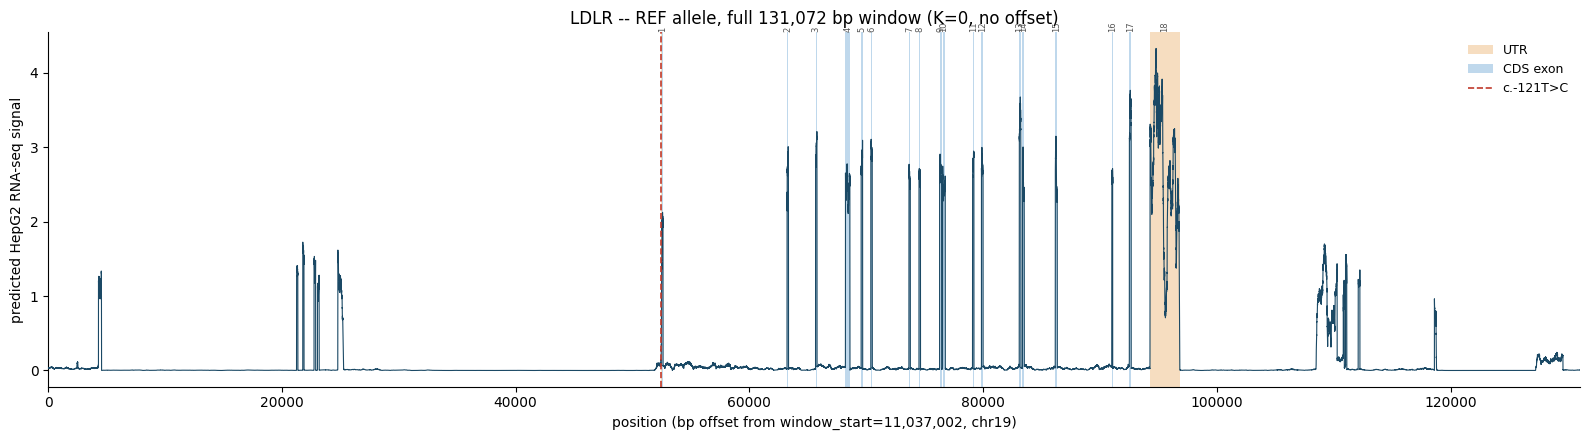

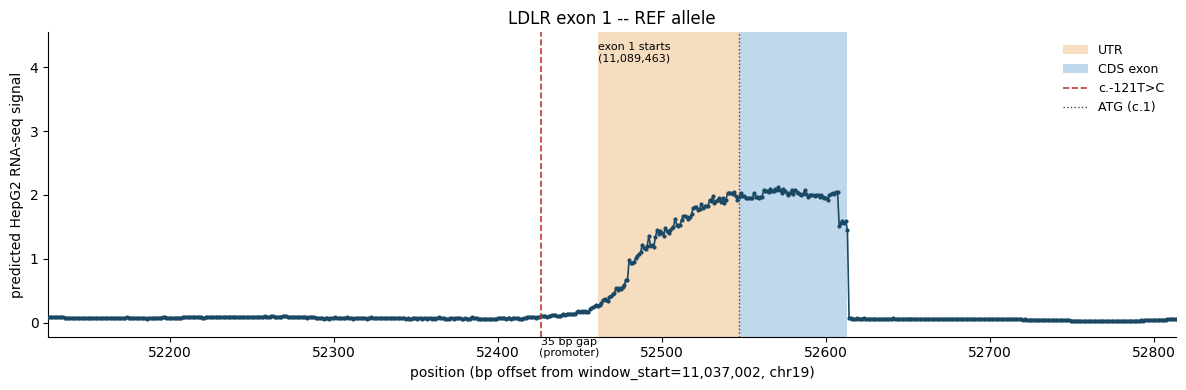

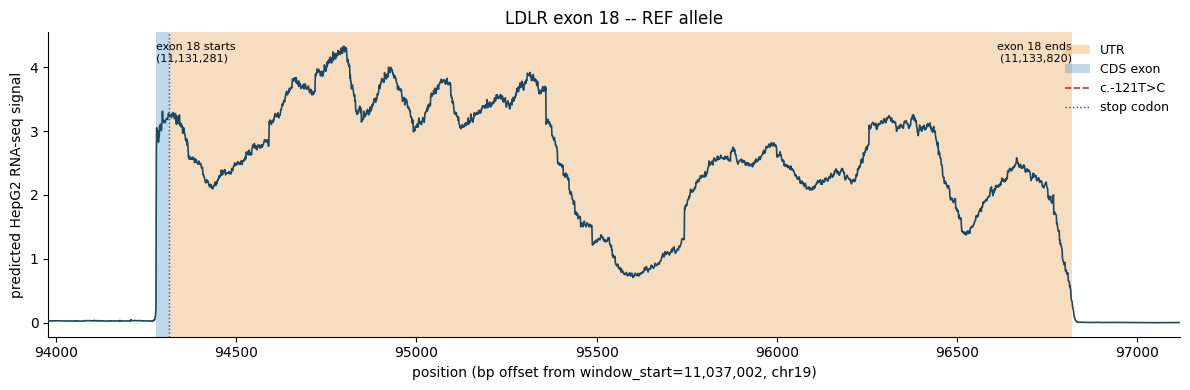

In [4]:
plot_three(signal_ref, "REF allele")

## Alt allele (`alt.npy`, c.-121T>C applied)

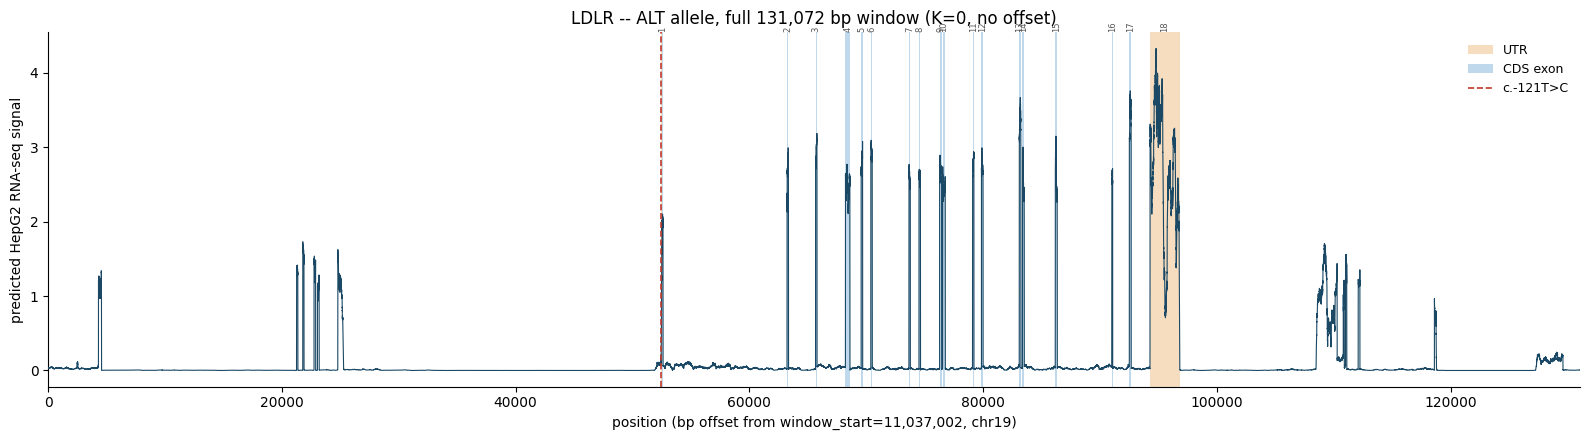

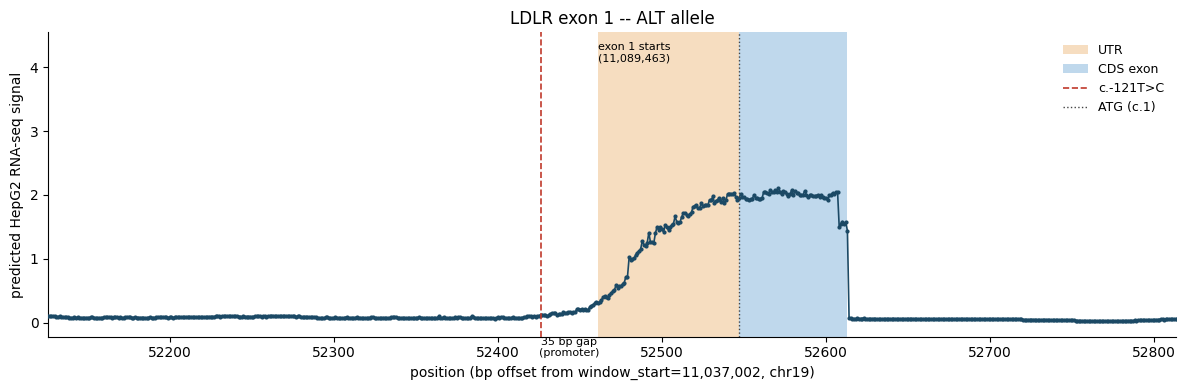

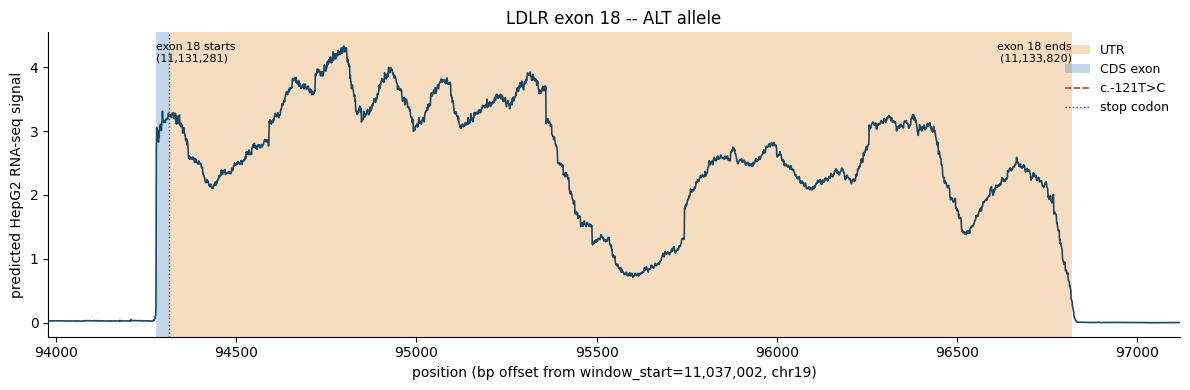

In [5]:
plot_three(signal_alt, "ALT allele")

## REF - ALT difference

Where does `c.-121T>C` actually change the predicted signal? Full window
first (a sanity check that nothing changes far from the variant), then
zoomed on the variant/exon 1 and exon 18 regions.

max |diff| = 0.0635  at offset 52496 (genomic 11,089,498)
|diff| > 0.01 at 722 / 131072 positions


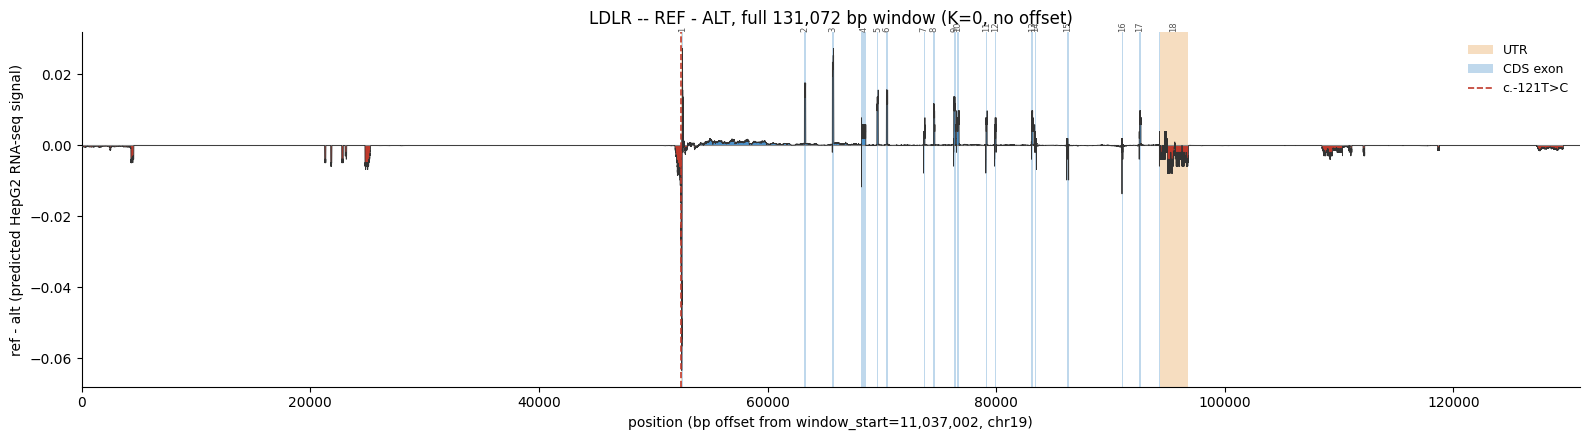

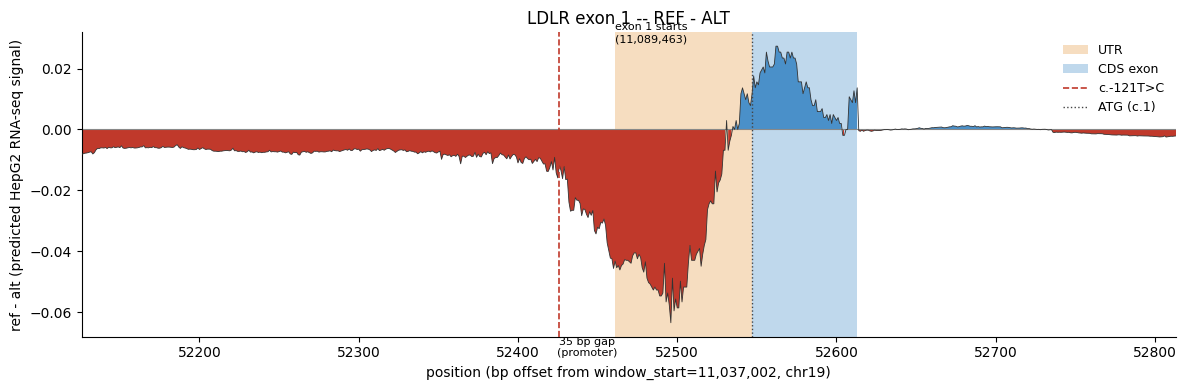

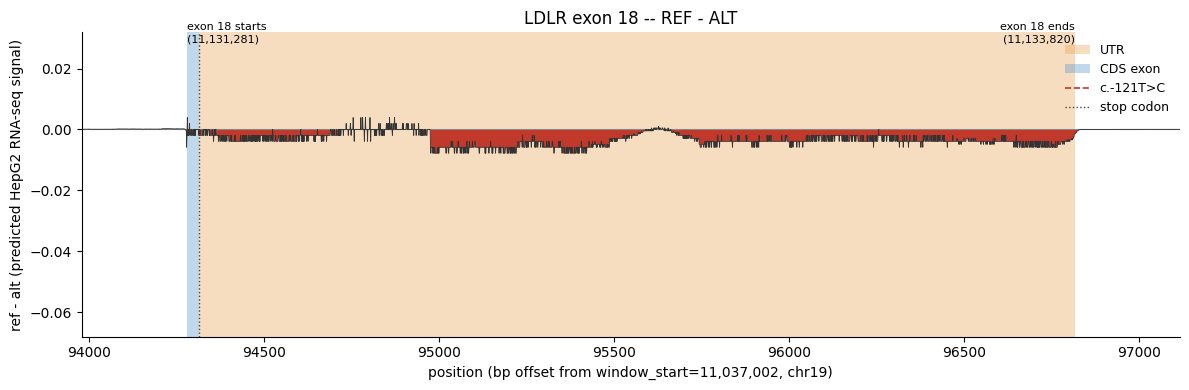

In [6]:
diff = signal_ref - signal_alt

print(f"max |diff| = {np.abs(diff).max():.4f}  at offset {np.argmax(np.abs(diff))} "
      f"(genomic {window_start + np.argmax(np.abs(diff)):,})")
print(f"|diff| > 0.01 at {int((np.abs(diff) > 0.01).sum())} / {len(diff)} positions")

plot_three(diff, "REF - ALT", diverging=True)

## REF - ALT, CDS only (spliced view)

Introns are spliced out and UTRs aren't translated, so the sequence that
actually becomes protein is the concatenation of just the coding portion of
each exon -- exon 1 from the ATG onward, exons 2-17 in full, exon 18 up to
and including the stop codon. Stitching those segments together (in
transcript order) removes the ~40 kb of intronic gaps between exons and
lines the exons up back-to-back, the way the ribosome actually sees them.
Dotted lines mark each exon-exon splice junction.

total CDS length: 2,565 bp  (855 codons incl. stop)


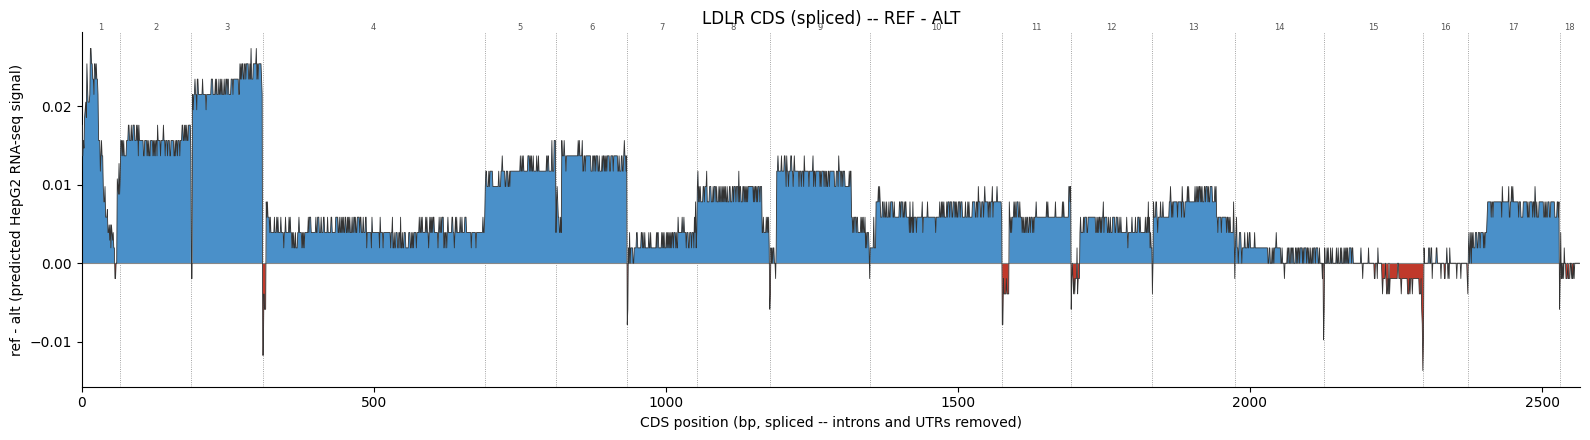

In [7]:
# CDS-only segment of each exon (exon 1: ATG onward; exon 18: up to incl. stop codon)
cds_segments = []
for _, e in exons_in_window.iterrows():
    if e["exon"] == 1:
        seg_start, seg_end = atg_off, e["end_off"]
    elif e["exon"] == 18:
        seg_start, seg_end = e["start_off"], cds_end_off
    else:
        seg_start, seg_end = e["start_off"], e["end_off"]
    cds_segments.append((int(e["exon"]), int(seg_start), int(seg_end)))

cds_lengths = [seg_end - seg_start for _, seg_start, seg_end in cds_segments]
cds_junction_pos = np.cumsum(cds_lengths)  # cumulative CDS-space position after each exon
cds_exon_labels = [exon for exon, _, _ in cds_segments]

print(f"total CDS length: {sum(cds_lengths):,} bp  ({sum(cds_lengths) / 3:.0f} codons incl. stop)")


def splice_cds(sig):
    """Concatenate only the CDS bases of each exon, in transcript order."""
    return np.concatenate([sig[seg_start:seg_end] for _, seg_start, seg_end in cds_segments])


def plot_cds_only(sig, title, diverging=False):
    sig_cds = splice_cds(sig)
    x_cds = np.arange(len(sig_cds))

    fig, ax = plt.subplots(figsize=(16, 4.5))

    if diverging:
        ax.fill_between(x_cds, 0, sig_cds, where=(sig_cds >= 0), color=COLOR_UP, linewidth=0, zorder=2)
        ax.fill_between(x_cds, 0, sig_cds, where=(sig_cds < 0), color=COLOR_DOWN, linewidth=0, zorder=2)
        ax.plot(x_cds, sig_cds, color="#333333", linewidth=0.6, zorder=3)
        ax.axhline(0, color="#888888", linewidth=0.8, zorder=2)
        ylabel = "ref - alt (predicted HepG2 RNA-seq signal)"
    else:
        ax.plot(x_cds, sig_cds, color=COLOR_SIGNAL, linewidth=0.8, zorder=3)
        ylabel = "predicted HepG2 RNA-seq signal"

    junction_start = 0
    for exon, junction_end in zip(cds_exon_labels, cds_junction_pos):
        ax.axvline(junction_end, color="#888888", linewidth=0.6, linestyle=":", zorder=1)
        ax.text((junction_start + junction_end) / 2, 1.0, str(exon), transform=ax.get_xaxis_transform(),
                fontsize=6, ha="center", va="bottom", color="#555555")
        junction_start = junction_end

    ax.set_xlim(0, len(sig_cds))
    ax.set_xlabel("CDS position (bp, spliced -- introns and UTRs removed)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()


plot_cds_only(diff, "LDLR CDS (spliced) -- REF - ALT", diverging=True)

## REF - ALT across variant-to-TSS distance (CDS only)

`K` is the number of random bp inserted immediately after the anchor
(c.-118, between the variant and the TSS) -- see `create_variant_data_LDLR.ipynb`.
Everything downstream of the anchor (the remaining real anchor-to-TSS
sequence, the TSS itself, and every exon) is left untouched and keeps the
same array offset regardless of `K`; only the far-upstream real sequence is
trimmed to compensate and hold the window length fixed. Net effect: `K`
extra random bp are spliced in between the variant and the TSS, so the true
variant-to-TSS distance for a given row is `K + gap_bp` (`gap_bp` = 35 bp,
the real variant-to-TSS distance at `K=0` -- one more than `c.-120C>T`'s 34 bp,
since this variant is 1 bp further upstream).

A heatmap (CDS position x variant-to-TSS distance) of ref-alt, and a
summary line of the mean (ref-alt) across the CDS at each distance.

In [8]:
meta_sorted = meta.sort_values("window_idx").reset_index(drop=True)
assert (meta_sorted["window_idx"] == np.arange(len(meta_sorted))).all()
k_values = meta_sorted["K"].to_numpy()
var_tss_dist = k_values + gap_bp  # true variant-to-TSS distance (bp) for each row

# flatten cds_segments into one fancy-index array so every row can be sliced at once
cds_idx = np.concatenate([np.arange(seg_start, seg_end) for _, seg_start, seg_end in cds_segments])
assert len(cds_idx) == sum(cds_lengths)

ref_cds_all = np.asarray(ref[:, cds_idx], dtype=np.float32)   # (1639, 2565)
alt_cds_all = np.asarray(alt[:, cds_idx], dtype=np.float32)
diff_cds_all = ref_cds_all - alt_cds_all

print(f"diff_cds_all shape: {diff_cds_all.shape}  (rows x spliced CDS bp)")
print(f"variant-to-TSS distance ranges {var_tss_dist[0]}-{var_tss_dist[-1]:,} bp")

diff_cds_all shape: (1639, 2565)  (rows x spliced CDS bp)
variant-to-TSS distance ranges 35-52,451 bp


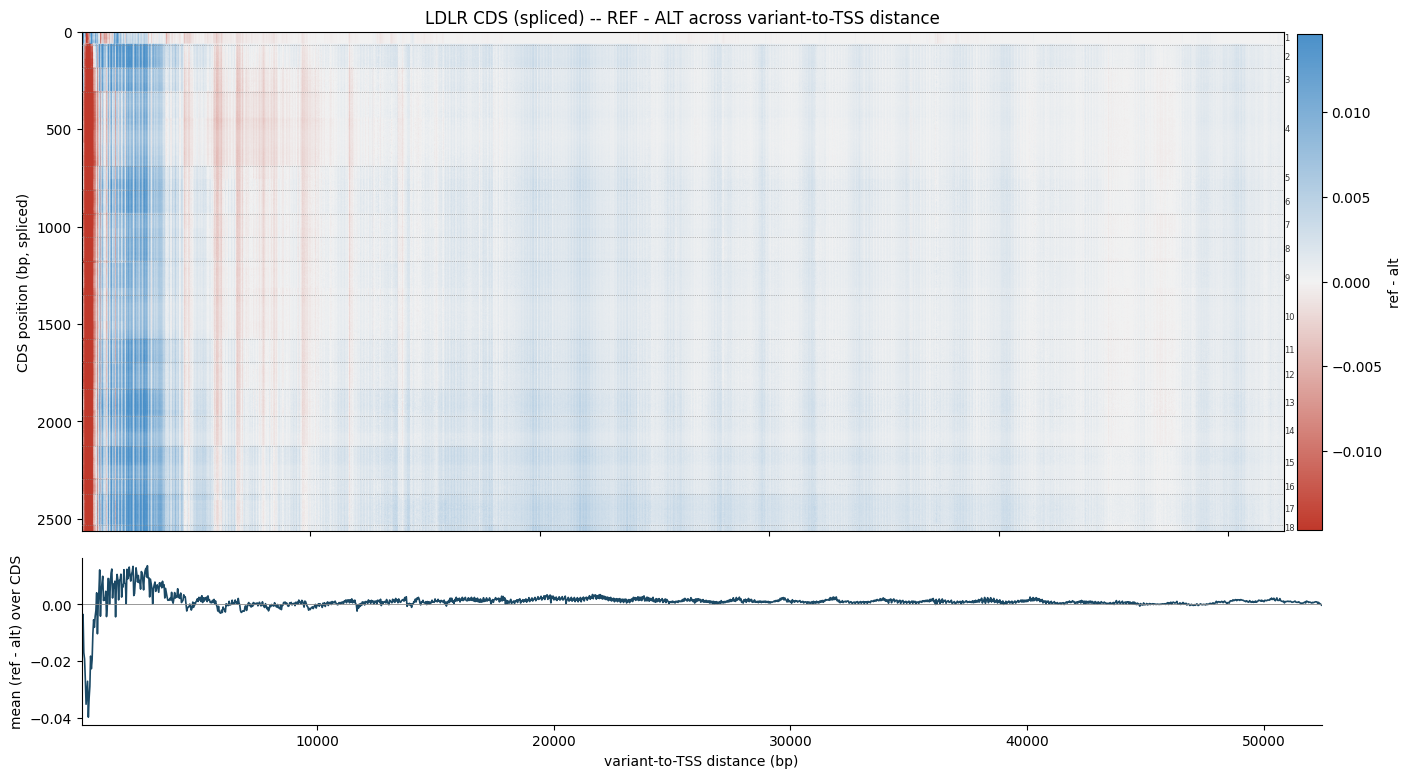

In [9]:
from matplotlib.colors import LinearSegmentedColormap

diverging_cmap = LinearSegmentedColormap.from_list("ref_alt_diverging", [COLOR_DOWN, "#f2f2f2", COLOR_UP])
vmax = np.percentile(np.abs(diff_cds_all), 99)  # robust to a few outlier bp
cds_len = diff_cds_all.shape[1]

# both panels share the variant-to-TSS-distance axis (x) -- heatmap needs CDS position on y, so transpose
fig, (ax_hm, ax_line) = plt.subplots(
    2, 1, figsize=(16, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08}
)

im = ax_hm.imshow(
    diff_cds_all.T, aspect="auto", cmap=diverging_cmap, vmin=-vmax, vmax=vmax,
    extent=[var_tss_dist[0], var_tss_dist[-1], cds_len, 0], zorder=2,
)
cbar = fig.colorbar(im, ax=ax_hm, pad=0.01, fraction=0.02)
cbar.set_label("ref - alt")

junction_start = 0
for exon, junction_end in zip(cds_exon_labels, cds_junction_pos):
    ax_hm.axhline(junction_end, color="#888888", linewidth=0.5, linestyle=":", zorder=3)
    ax_hm.text(1.0, (junction_start + junction_end) / 2, str(exon), transform=ax_hm.get_yaxis_transform(),
               fontsize=6, ha="left", va="center", color="#333333")
    junction_start = junction_end

ax_hm.set_ylabel("CDS position (bp, spliced)")
ax_hm.set_title("LDLR CDS (spliced) -- REF - ALT across variant-to-TSS distance")

mean_diff = diff_cds_all.mean(axis=1)  # signed mean, plain arithmetic mean over the 2,565 CDS positions

ax_line.plot(var_tss_dist, mean_diff, color=COLOR_SIGNAL, linewidth=1.2)
ax_line.axhline(0, color="#888888", linewidth=0.6)
ax_line.set_xlabel("variant-to-TSS distance (bp)")
ax_line.set_ylabel("mean (ref - alt) over CDS")
ax_line.spines["top"].set_visible(False)
ax_line.spines["right"].set_visible(False)

plt.show()